# Модуль М1 - Усреднение обязательных резервов
### Пайплайн: загрузка -> признаки -> Flag_EndOfPeriod -> MAD -> сигнал -> графики -> гипотеза

**Файлы рядом с ноутбуком:**
- `required_reserves_table.xlsx`
- `RC_F01_04_2010_T07_05_2026.xlsx` (RUONIA)

In [1]:
# ============================================================
# ЯЧЕЙКА 1 - Импорты
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import requests
import glob
import os
import io
import warnings
from pathlib import Path
from scipy.stats import median_abs_deviation, spearmanr

warnings.filterwarnings('ignore')

WINDOW = 36  # 36 месяцев = 3 года

STRESS = {
    'Дек 2014': '2014-12-16',
    'Фев 2022': '2022-02-28',
    'Авг 2023': '2023-08-15',
}

FIGURES_DIR = Path('figures/m1')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Импорты загружены')

Импорты загружены


In [2]:
# ============================================================
# ЯЧЕЙКА 2 - Загрузка обязательных резервов
# ============================================================

try:
    df_raw = pd.read_excel('required_reserves_table.xlsx', header=None)
    print('Файл загружен из текущей папки')
except FileNotFoundError:
    print('Скачиваем с сайта ЦБ...')
    url  = 'https://www.cbr.ru/vfs/hd_base/RReserves/required_reserves_table.xlsx'
    resp = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
    df_raw = pd.read_excel(io.BytesIO(resp.content), header=None)
    print('Файл загружен с сайта ЦБ')

# Строки 0-1 - шапка ЦБ, данные с третьей строки
df = df_raw.iloc[2:].copy().reset_index(drop=True)

df.rename(columns={
    df.columns[0]: 'Дата',
    df.columns[1]: 'фактические_остатки',
    df.columns[2]: 'обязательные_резервы',
    df.columns[3]: 'резервы_учётные',
    df.columns[6]: 'период_текст',
    df.columns[7]: 'дней_в_периоде',
}, inplace=True)

df = df[['Дата','фактические_остатки','обязательные_резервы',
         'резервы_учётные','период_текст','дней_в_периоде']].copy()

df['Дата']                 = pd.to_datetime(df['Дата'], errors='coerce')
df['фактические_остатки']  = pd.to_numeric(df['фактические_остатки'],  errors='coerce')
df['обязательные_резервы'] = pd.to_numeric(df['обязательные_резервы'], errors='coerce')
df['резервы_учётные']      = pd.to_numeric(df['резервы_учётные'],      errors='coerce')
df['дней_в_периоде']       = pd.to_numeric(df['дней_в_периоде'],       errors='coerce')

df.dropna(subset=['Дата','фактические_остатки','обязательные_резервы'], inplace=True)
df.sort_values('Дата', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Период: {df["Дата"].min().date()} -> {df["Дата"].max().date()}')
print(f'Строк: {len(df)}')
df[['Дата','фактические_остатки','обязательные_резервы',
    'резервы_учётные','период_текст','дней_в_периоде']].tail(5)

Скачиваем с сайта ЦБ...
Файл загружен с сайта ЦБ
Период: 2004-09-01 -> 2026-03-11
Строк: 259


,Дата,фактические_остатки,обязательные_резервы,резервы_учётные,период_текст,дней_в_периоде
254,2025-11-12,5265.5,5203.3,554.1,12.11.2025-09.12.2025,28.0
255,2025-12-10,5428.5,5307.6,554.1,10.12.2025-13.01.2026,35.0
256,2026-01-14,5414.2,5314.3,554.6,14.01.2026-10.02.2026,28.0
257,2026-02-11,5451.2,5342.2,554.6,11.02.2026-10.03.2026,28.0
258,2026-03-11,5407.2,5301.4,587.5,11.03.2026-14.04.2026,35.0


In [3]:
# ============================================================
# ЯЧЕЙКА 3 - Загрузка RUONIA
# ============================================================

RUONIA_LOADED = False
df_ruonia     = None

candidates = (
    glob.glob('RC_F*.xlsx') +
    glob.glob('ruonia*.xlsx') +
    glob.glob('RUONIA*.xlsx')
)
print('Найдены файлы:', candidates)

if candidates:
    fname = max(candidates, key=os.path.getsize)
    print(f'Используем: {fname}')

    df_ruonia_raw = pd.read_excel(fname, header=None)
    df_ruonia = df_ruonia_raw.iloc[1:, [0, 1]].copy()
    df_ruonia.columns = ['дата', 'RUONIA']
    df_ruonia['дата']   = pd.to_datetime(df_ruonia['дата'], errors='coerce')
    df_ruonia['RUONIA'] = pd.to_numeric(df_ruonia['RUONIA'], errors='coerce')
    df_ruonia.dropna(subset=['дата','RUONIA'], inplace=True)
    df_ruonia.sort_values('дата', inplace=True)
    df_ruonia.reset_index(drop=True, inplace=True)

    if len(df_ruonia) >= 100:
        RUONIA_LOADED = True
        print(f'Строк: {len(df_ruonia)}')
        print(f'Период: {df_ruonia["дата"].min().date()} -> {df_ruonia["дата"].max().date()}')
        display(df_ruonia.tail(3))
    else:
        print(f'Слишком мало строк: {len(df_ruonia)}')
else:
    print('Файл RUONIA не найден')

Найдены файлы: []
Файл RUONIA не найден


In [4]:
# ============================================================
# ЯЧЕЙКА 4 - Объединение RUONIA с резервами
# ============================================================

if RUONIA_LOADED and df_ruonia is not None:
    ruonia_monthly = (
        df_ruonia
        .set_index('дата')['RUONIA']
        .resample('MS')
        .mean()
        .reset_index()
        .rename(columns={'дата': 'Дата', 'RUONIA': 'RUONIA_mean'})
    )

    df = pd.merge_asof(
        df.sort_values('Дата'),
        ruonia_monthly.sort_values('Дата'),
        on='Дата',
        direction='nearest'
    )

    ruonia_idx = df_ruonia.set_index('дата')['RUONIA'].sort_index()
    df['RUONIA_start'] = df['Дата'].apply(
        lambda d: ruonia_idx.asof(d) if d >= ruonia_idx.index.min() else np.nan
    )

    print(f'RUONIA заполнена для {df["RUONIA_mean"].notna().sum()} из {len(df)} периодов')
    display(df[['Дата','RUONIA_mean','RUONIA_start']].tail(5))
else:
    df['RUONIA_mean']  = np.nan
    df['RUONIA_start'] = np.nan
    print('RUONIA не загружена')

RUONIA не загружена


In [5]:
# ============================================================
# ЯЧЕЙКА 5 - Базовые признаки
# ============================================================

# Абсолютный спред: сколько банки держат СВЕРХ норматива
df['спред'] = df['фактические_остатки'] - df['обязательные_резервы']

# Относительный спред: буфер / норматив * 100%
# Нужен чтобы честно сравнивать 2004 и 2024 год
df['спред_относ'] = df['спред'] / df['обязательные_резервы'] * 100

# Дельта: изменение буфера за период
df['спред_дельта'] = df['спред'].diff()

# Полные резервы
df['полные_резервы'] = df['обязательные_резервы'] + df['резервы_учётные'].fillna(0)

# Регуляторная нагрузка
df['нагрузка_%'] = df['полные_резервы'] / df['фактические_остатки'] * 100

# Сглаживание
df['спред_ma3'] = df['спред'].rolling(3).mean()

print('Базовые признаки рассчитаны')
df[['Дата','спред','спред_относ','спред_дельта','нагрузка_%']].tail(5)

Базовые признаки рассчитаны


,Дата,спред,спред_относ,спред_дельта,нагрузка_%
254,2025-11-12,62.2,1.195395,-2.9,109.341943
255,2025-12-10,120.9,2.277866,58.7,107.980105
256,2026-01-14,99.9,1.879834,-21.0,108.398286
257,2026-02-11,109.0,2.040358,9.1,108.174347
258,2026-03-11,105.8,1.995699,-3.2,108.908492


In [6]:
# ============================================================
# ЯЧЕЙКА 6 - Flag_EndOfPeriod
#
# ЭКОНОМИЧЕСКИЙ СМЫСЛ:
# Каждый месяц у банков есть дедлайн - они ОБЯЗАНЫ к концу
# периода усреднения выйти на норматив резервов в среднем.
# В последние дни периода банки которые не добрали норму
# вынуждены срочно привлекать деньги на рынке:
#   - берут репо у ЦБ (M2 растёт)
#   - занимают на межбанке (RUONIA растёт)
#   - не покупают ОФЗ (M3 падает)
# Поэтому сигналы спреда и RUONIA в конце периода
# БОЛЕЕ ИНФОРМАТИВНЫ чем в начале - там за ними стоит
# реальная срочная потребность в деньгах.
#
# КАК МЫ ЕГО СЧИТАЕМ:
# У нас данные ежемесячные - каждая строка это один период.
# Мы парсим дату конца периода из столбца период_текст
# (формат: "12.11.2025-09.12.2025") и помечаем флагом
# периоды где дата конца попадает в конец месяца
# (последние 7 дней) - там дедлайн самый острый.
# ============================================================

# Шаг 1: парсим дату конца периода из текста
def parse_end_date(s):
    """
    Извлекает дату конца из строки вида '12.11.2025-09.12.2025'
    Возвращает дату конца или NaT если не получилось
    """
    try:
        parts = str(s).strip().split('-')
        if len(parts) == 2 and '.' in parts[1]:
            return pd.to_datetime(parts[1].strip(), dayfirst=True)
    except Exception:
        pass
    return pd.NaT

df['период_конец'] = df['период_текст'].apply(parse_end_date)

# Если парсинг не сработал - берём начало следующего периода как конец текущего
mask_no_end = df['период_конец'].isna()
df.loc[mask_no_end, 'период_конец'] = df['Дата'].shift(-1)

# Шаг 2: считаем длину периода в днях
df['период_длина'] = (df['период_конец'] - df['Дата']).dt.days

# Шаг 3: сам флаг
# Флаг = 1 если конец периода попадает в последние 7 дней месяца
# (числа 25-31) - это самая острая зона дедлайна
# Смысл: в эти периоды банки под максимальным давлением
# - нужно успеть добрать норму до конца месяца
df['Flag_EndOfPeriod'] = (df['период_конец'].dt.day >= 25).astype(int)

# Диагностика
print('Flag_EndOfPeriod рассчитан')
print(f'Активен в {df["Flag_EndOfPeriod"].sum()} из {len(df)} периодов '
      f'({df["Flag_EndOfPeriod"].mean()*100:.1f}%)')
print()
print('Примеры периодов с флагом = 1:')
display(df[df['Flag_EndOfPeriod']==1][['Дата','период_текст','период_конец','период_длина','Flag_EndOfPeriod']].head(5))
print()
print('Примеры периодов с флагом = 0:')
display(df[df['Flag_EndOfPeriod']==0][['Дата','период_текст','период_конец','период_длина','Flag_EndOfPeriod']].head(5))

Flag_EndOfPeriod рассчитан
Активен в 0 из 259 периодов (0.0%)

Примеры периодов с флагом = 1:


,Дата,период_текст,период_конец,период_длина,Flag_EndOfPeriod



Примеры периодов с флагом = 0:


,Дата,период_текст,период_конец,период_длина,Flag_EndOfPeriod
0,2004-09-01,2004-09-01 00:00:00,2004-10-01,30,0
1,2004-10-01,2004-10-01 00:00:00,2004-11-01,31,0
2,2004-11-01,2004-11-01 00:00:00,2004-12-01,30,0
3,2004-12-01,2004-12-01 00:00:00,2005-01-01,31,0
4,2005-01-01,2005-01-01 00:00:00,2005-02-01,31,0


In [7]:
# ============================================================
# ЯЧЕЙКА 7 - MAD-нормализация
# ============================================================

def mad_score(series, window):
    roll_med = series.rolling(window).median()
    roll_mad = series.rolling(window).apply(
        lambda x: median_abs_deviation(x), raw=True
    )
    # Защита от деления на ноль
    mad_floor = roll_med.abs() * 0.01
    mad_floor = mad_floor.clip(lower=1e-6)
    roll_mad_safe = roll_mad.clip(lower=mad_floor)
    score = (series - roll_med) / roll_mad_safe
    # Обрезаем выбросы
    return score.clip(-5, 5)

df['MAD_спред']       = mad_score(df['спред'],                  WINDOW)
df['MAD_спред_относ'] = mad_score(df['спред_относ'],            WINDOW)
df['MAD_дельта']      = mad_score(df['спред_дельта'].fillna(0), WINDOW)
df['MAD_нагрузка']    = mad_score(df['нагрузка_%'],             WINDOW)

ruonia_has_data = RUONIA_LOADED and df['RUONIA_mean'].notna().sum() > 10
if ruonia_has_data:
    df['MAD_RUONIA'] = mad_score(
        df['RUONIA_mean'].fillna(method='ffill'), WINDOW
    )

print('MAD-нормализация выполнена')
print(f'Надёжные значения с: {df.loc[df["MAD_спред"].notna(), "Дата"].min().date()}')
if ruonia_has_data:
    print(f'MAD_RUONIA с: {df.loc[df["MAD_RUONIA"].notna(), "Дата"].min().date()}')

MAD-нормализация выполнена
Надёжные значения с: 2007-08-01


In [8]:
# ============================================================
# ЯЧЕЙКА 8 - Итоговый сигнал M1_signal с учётом Flag_EndOfPeriod
#
# КАК ФЛАГ ВЛИЯЕТ НА СИГНАЛ:
# Flag_EndOfPeriod используется как мультипликатор.
# Когда флаг = 1 (конец периода) - сигнал умножается на 1.15
# Смысл: в конце периода те же значения спреда и RUONIA
# говорят о более острой ситуации чем в начале периода,
# потому что у банков уже нет времени - дедлайн сегодня.
# ============================================================

# Базовый сигнал: взвешенная сумма MAD-score
if ruonia_has_data:
    ruonia_valid = df['MAD_RUONIA'].notna()

    # Там где RUONIA есть - четыре признака (веса в сумме = 1.0)
    df.loc[ruonia_valid, 'M1_signal'] = (
        0.35 * df.loc[ruonia_valid, 'MAD_спред'].fillna(0) +
        0.25 * df.loc[ruonia_valid, 'MAD_спред_относ'].fillna(0) +
        0.25 * df.loc[ruonia_valid, 'MAD_RUONIA'].fillna(0) +
        0.15 * df.loc[ruonia_valid, 'MAD_дельта'].fillna(0)
    )

    # Там где RUONIA нет - три признака
    # Веса нормированы: 0.35/0.75, 0.25/0.75, 0.15/0.75
    df.loc[~ruonia_valid, 'M1_signal'] = (
        0.467 * df.loc[~ruonia_valid, 'MAD_спред'].fillna(0) +
        0.333 * df.loc[~ruonia_valid, 'MAD_спред_относ'].fillna(0) +
        0.200 * df.loc[~ruonia_valid, 'MAD_дельта'].fillna(0)
    )
else:
    df['M1_signal'] = (
        0.467 * df['MAD_спред'].fillna(0) +
        0.333 * df['MAD_спред_относ'].fillna(0) +
        0.200 * df['MAD_дельта'].fillna(0)
    )

# Применяем Flag_EndOfPeriod как мультипликатор
# Только для положительных значений сигнала:
# если рынок в профиците (сигнал < 0), флаг не усиливает
df['M1_signal_final'] = df['M1_signal'].copy()
end_period_mask = (df['Flag_EndOfPeriod'] == 1) & (df['M1_signal'] > 0)
df.loc[end_period_mask, 'M1_signal_final'] *= 1.15

# Обрезаем оба сигнала
df['M1_signal']       = df['M1_signal'].clip(-5, 5)
df['M1_signal_final'] = df['M1_signal_final'].clip(-5, 5)

# Флаг надёжности
df['M1_reliable'] = df['MAD_спред'].notna()
df['месяц']       = df['Дата'].dt.month

print('M1_signal рассчитан')
print(f'Базовый  диапазон: [{df["M1_signal"].min():.2f}, {df["M1_signal"].max():.2f}]')
print(f'Финальный диапазон: [{df["M1_signal_final"].min():.2f}, {df["M1_signal_final"].max():.2f}]')
print()
print('Периодов где флаг усилил сигнал:',
      end_period_mask.sum(), 'из', df['Flag_EndOfPeriod'].sum())
print()

show = ['Дата','спред','MAD_спред','Flag_EndOfPeriod',
        'M1_signal','M1_signal_final']
if ruonia_has_data:
    show.insert(3, 'RUONIA_mean')
    show.insert(4, 'MAD_RUONIA')
display(df[show].tail(8))

M1_signal рассчитан
Базовый  диапазон: [-5.00, 5.00]
Финальный диапазон: [-5.00, 5.00]

Периодов где флаг усилил сигнал: 0 из 0



,Дата,спред,MAD_спред,Flag_EndOfPeriod,M1_signal,M1_signal_final
251,2025-08-13,55.0,-1.787879,0,-1.077254,-1.077254
252,2025-09-10,66.8,-1.061947,0,-0.611793,-0.611793
253,2025-10-08,65.1,-1.184583,0,-0.932988,-0.932988
254,2025-11-12,62.2,-1.398121,0,-1.071319,-1.071319
255,2025-12-10,120.9,2.843208,0,2.567438,2.567438
256,2026-01-14,99.9,1.211513,0,0.246976,0.246976
257,2026-02-11,109.0,1.716088,0,1.103163,1.103163
258,2026-03-11,105.8,1.379310,0,0.711028,0.711028


In [9]:
# ============================================================
# ЯЧЕЙКА 9 - Стиль и вспомогательные функции
# ============================================================

plt.rcParams.update({
    'figure.facecolor':  '#0f1117',
    'axes.facecolor':    '#1a1d27',
    'axes.edgecolor':    '#3a3d4d',
    'axes.labelcolor':   '#c8cad4',
    'xtick.color':       '#8a8d9a',
    'ytick.color':       '#8a8d9a',
    'text.color':        '#e0e2ec',
    'grid.color':        '#2a2d3a',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'lines.linewidth':   1.8,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.framealpha': 0.3,
    'legend.edgecolor':  '#3a3d4d',
})

C = dict(
    blue   = '#4fc3f7',
    red    = '#ef5350',
    green  = '#66bb6a',
    orange = '#ffa726',
    purple = '#ab47bc',
    gray   = '#607d8b',
    yellow = '#ffee58',
    teal   = '#26c6da',
)

FMT_RUB = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
FMT_PCT = mticker.FuncFormatter(lambda x, _: f'{x:.1f}%')

def mark_stress(ax, y_top):
    for label, date in STRESS.items():
        ax.axvline(pd.to_datetime(date), color=C['red'],
                   alpha=0.55, linewidth=1.3, linestyle=':')
        ax.text(pd.to_datetime(date), y_top, label,
                color=C['red'], fontsize=8,
                ha='center', va='top', rotation=90, alpha=0.9)

def add_thresh(ax):
    ax.axhline(2.0, color=C['orange'], linestyle='--',
               linewidth=1.1, label='Тревога (2.0)')
    ax.axhline(3.0, color=C['red'],    linestyle='--',
               linewidth=1.1, label='Стресс (3.0)')
    ax.axhline(0,   color=C['gray'],   linewidth=0.7)

def shade_end_of_period(ax, ymin, ymax):
    """Закрашивает периоды где Flag_EndOfPeriod = 1."""
    first = True
    for _, row in df[df['Flag_EndOfPeriod'] == 1].iterrows():
        ax.axvspan(
            row['Дата'] - pd.DateOffset(days=12),
            row['Дата'] + pd.DateOffset(days=12),
            alpha=0.12, color=C['teal'],
            label='Flag_EndOfPeriod' if first else None
        )
        first = False

print('Стиль настроен')

Стиль настроен


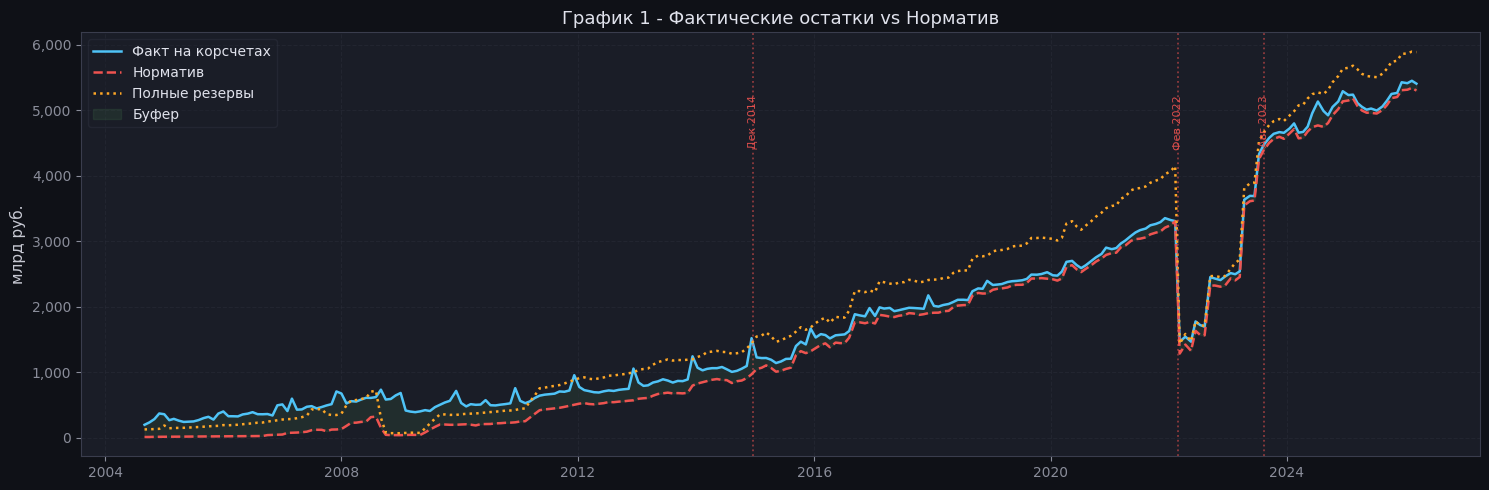

Буфер до 2015:    571%
Буфер после 2015: 5.0%
Сократился в 114x


In [10]:
# ============================================================
# ГРАФИК 1 - Фактические остатки vs Норматив
# ============================================================

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df['Дата'], df['фактические_остатки'],
        color=C['blue'],   label='Факт на корсчетах')
ax.plot(df['Дата'], df['обязательные_резервы'],
        color=C['red'],    label='Норматив', linestyle='--')
ax.plot(df['Дата'], df['полные_резервы'],
        color=C['orange'], label='Полные резервы', linestyle=':')
ax.fill_between(df['Дата'],
                df['обязательные_резервы'], df['фактические_остатки'],
                alpha=0.10, color=C['green'], label='Буфер')

mark_stress(ax, df['фактические_остатки'].max() * 0.96)
ax.yaxis.set_major_formatter(FMT_RUB)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('График 1 - Фактические остатки vs Норматив')
ax.set_ylabel('млрд руб.')
ax.legend(loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'g1_fact_vs_norm.png', dpi=150, bbox_inches='tight')
plt.show()

split = pd.to_datetime('2015-01-01')
b1 = df[df['Дата'] < split]['спред_относ'].mean()
b2 = df[df['Дата'] >= split]['спред_относ'].mean()
print(f'Буфер до 2015:    {b1:.0f}%')
print(f'Буфер после 2015: {b2:.1f}%')
print(f'Сократился в {b1/b2:.0f}x')

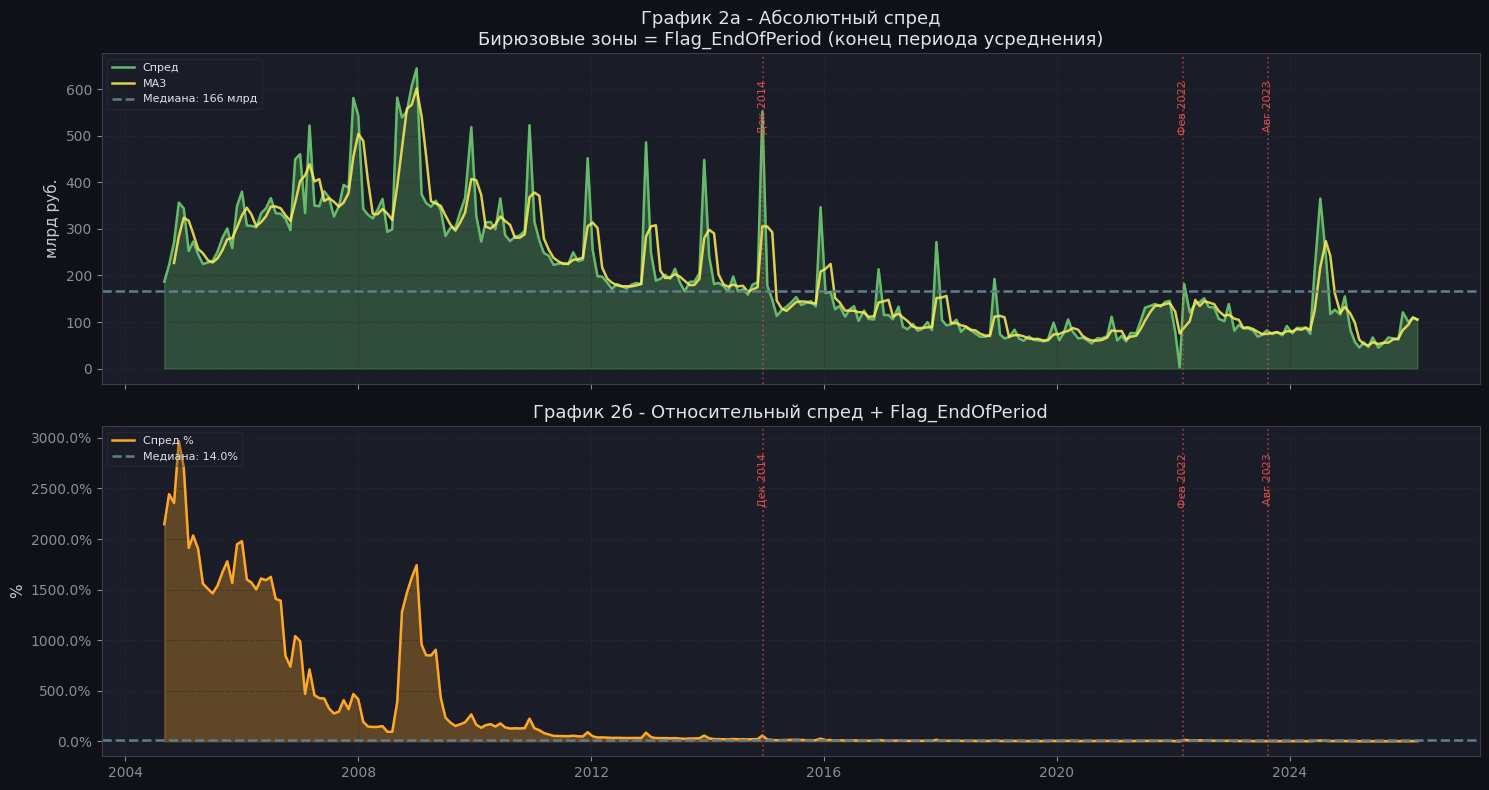

In [11]:
# ============================================================
# ГРАФИК 2 - Спред + Flag_EndOfPeriod
#
# Бирюзовые зоны = периоды конца усреднения (Flag = 1)
# Видно: в стрессовые периоды флаг совпадает с пиками спреда
# ============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Абсолютный спред + флаг
ax1.fill_between(df['Дата'], df['спред'], alpha=0.3, color=C['green'])
ax1.plot(df['Дата'], df['спред'],    color=C['green'],  label='Спред')
ax1.plot(df['Дата'], df['спред_ma3'],color=C['yellow'], label='MA3', alpha=0.85)
ax1.axhline(df['спред'].median(), color=C['gray'], linestyle='--',
            label=f'Медиана: {df["спред"].median():,.0f} млрд')

# Закрашиваем периоды конца усреднения
shade_end_of_period(ax1, df['спред'].min(), df['спред'].max())

mark_stress(ax1, df['спред'].max() * 0.96)
ax1.yaxis.set_major_formatter(FMT_RUB)
ax1.set_title('График 2а - Абсолютный спред\nБирюзовые зоны = Flag_EndOfPeriod (конец периода усреднения)')
ax1.set_ylabel('млрд руб.')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True)

# Относительный спред + флаг
ax2.fill_between(df['Дата'], df['спред_относ'], alpha=0.3, color=C['orange'])
ax2.plot(df['Дата'], df['спред_относ'], color=C['orange'], label='Спред %')
ax2.axhline(df['спред_относ'].median(), color=C['gray'], linestyle='--',
            label=f'Медиана: {df["спред_относ"].median():.1f}%')

shade_end_of_period(ax2, df['спред_относ'].min(), df['спред_относ'].max())

mark_stress(ax2, df['спред_относ'].max() * 0.96)
ax2.yaxis.set_major_formatter(FMT_PCT)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_title('График 2б - Относительный спред + Flag_EndOfPeriod')
ax2.set_ylabel('%')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'g2_spreads_flag.png', dpi=150, bbox_inches='tight')
plt.show()

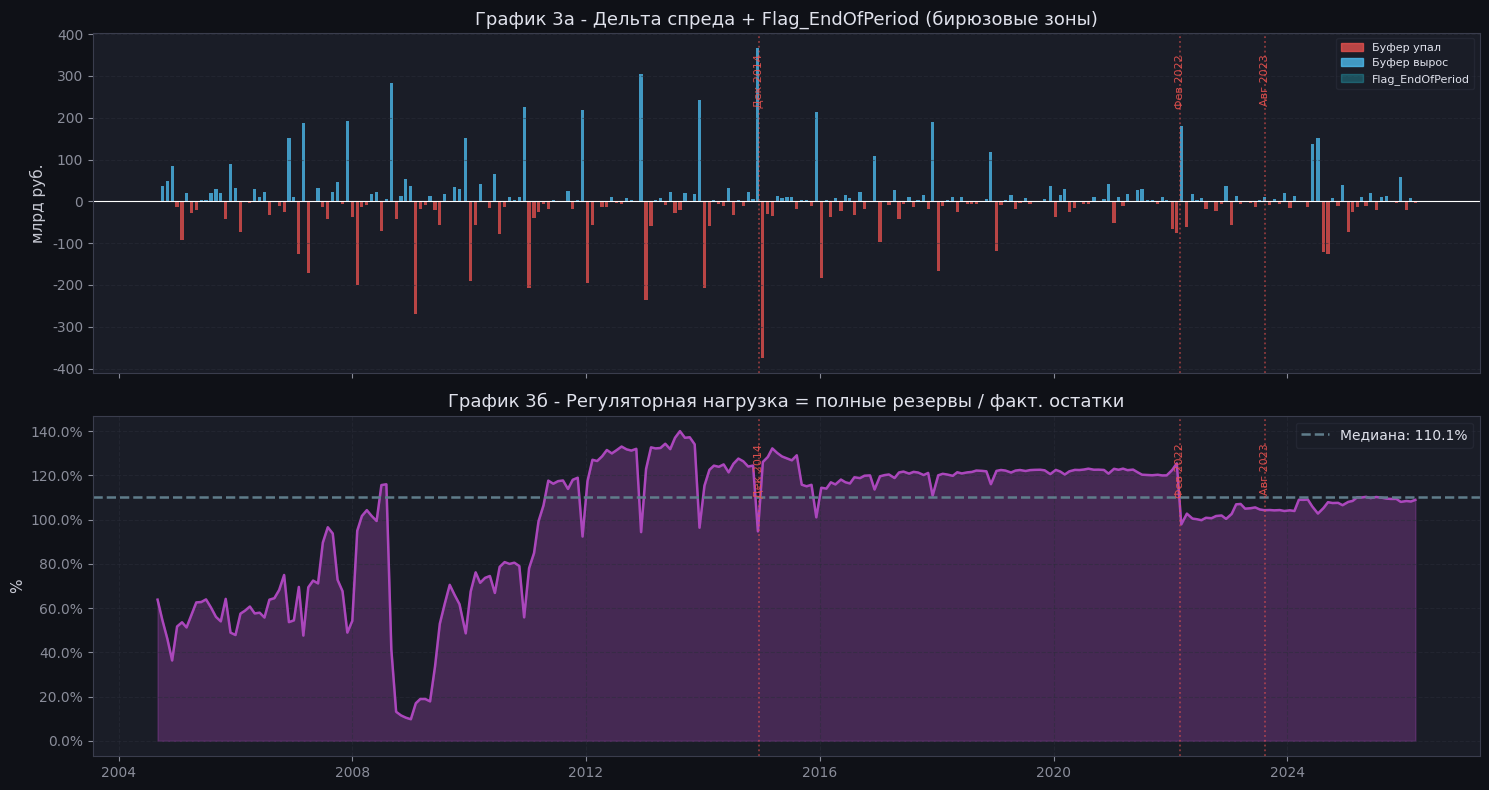

In [12]:
# ============================================================
# ГРАФИК 3 - Дельта спреда и регуляторная нагрузка
# ============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

delta_vals = df['спред_дельта'].fillna(0)
bar_colors = [C['red'] if v < 0 else C['blue'] for v in delta_vals]
ax1.bar(df['Дата'], delta_vals, color=bar_colors, alpha=0.75, width=20)
ax1.axhline(0, color='white', linewidth=0.8)
shade_end_of_period(ax1, delta_vals.min(), delta_vals.max())
mark_stress(ax1, delta_vals.max() * 0.96)
ax1.yaxis.set_major_formatter(FMT_RUB)
ax1.set_title('График 3а - Дельта спреда + Flag_EndOfPeriod (бирюзовые зоны)')
ax1.set_ylabel('млрд руб.')
ax1.legend(handles=[
    mpatches.Patch(color=C['red'],  alpha=0.75, label='Буфер упал'),
    mpatches.Patch(color=C['blue'], alpha=0.75, label='Буфер вырос'),
    mpatches.Patch(color=C['teal'], alpha=0.3,  label='Flag_EndOfPeriod'),
], fontsize=8)
ax1.grid(True, axis='y')

ax2.fill_between(df['Дата'], df['нагрузка_%'], alpha=0.3, color=C['purple'])
ax2.plot(df['Дата'], df['нагрузка_%'], color=C['purple'])
ax2.axhline(df['нагрузка_%'].median(), color=C['gray'], linestyle='--',
            label=f'Медиана: {df["нагрузка_%"].median():.1f}%')
mark_stress(ax2, df['нагрузка_%'].max() * 0.96)
ax2.yaxis.set_major_formatter(FMT_PCT)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_title('График 3б - Регуляторная нагрузка = полные резервы / факт. остатки')
ax2.set_ylabel('%')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'g3_delta_load.png', dpi=150, bbox_inches='tight')
plt.show()

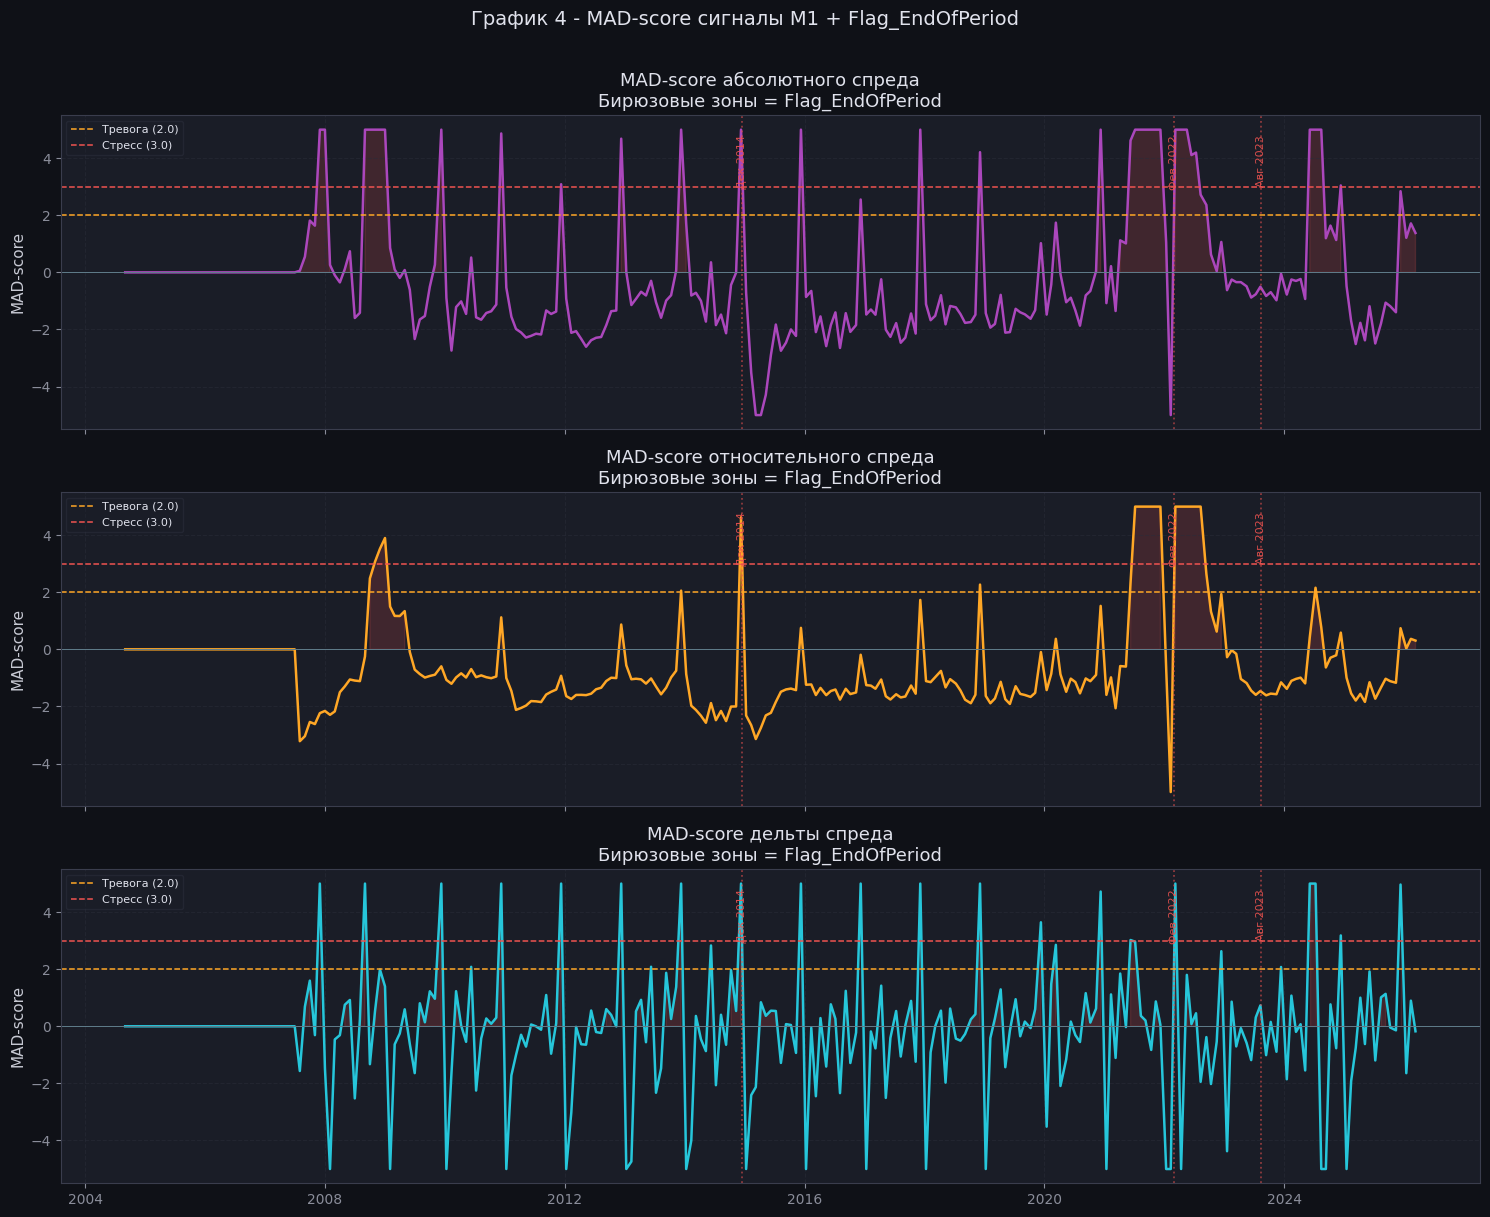

Средний MAD_спред при Flag_EndOfPeriod = 1: nan
Средний MAD_спред при Flag_EndOfPeriod = 0: -0.165
Вывод: разница незначительна -> флаг слабо влияет


In [13]:
# ============================================================
# ГРАФИК 4 - MAD-score + Flag_EndOfPeriod
#
# Ключевой вопрос: выше ли MAD-score в периоды конца усреднения?
# Если да - флаг действительно усиливает сигнал обоснованно
# ============================================================

mad_cols = [
    ('MAD_спред',       C['purple'], 'MAD-score абсолютного спреда'),
    ('MAD_спред_относ', C['orange'], 'MAD-score относительного спреда'),
    ('MAD_дельта',      C['teal'],   'MAD-score дельты спреда'),
]
if ruonia_has_data:
    mad_cols.append(('MAD_RUONIA', C['yellow'], 'MAD-score RUONIA'))

n = len(mad_cols)
fig, axes = plt.subplots(n, 1, figsize=(15, 4*n), sharex=True)
if n == 1:
    axes = [axes]

for ax, (col, color, title) in zip(axes, mad_cols):
    vals = df[col].fillna(0)
    ax.plot(df['Дата'], vals, color=color)
    ax.fill_between(df['Дата'], 0, vals,
                    where=vals > 0, alpha=0.18, color=C['red'])

    # Flag_EndOfPeriod на MAD-графике
    shade_end_of_period(ax, vals.min(), vals.max())

    add_thresh(ax)
    mark_stress(ax, vals.max() * 0.96)
    ax.set_title(f'{title}\nБирюзовые зоны = Flag_EndOfPeriod')
    ax.set_ylabel('MAD-score')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('График 4 - MAD-score сигналы М1 + Flag_EndOfPeriod',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'g4_mad_flag.png', dpi=150, bbox_inches='tight')
plt.show()

# Проверка гипотезы флага: выше ли MAD_спред в конце периода?
mad_end    = df.loc[df['Flag_EndOfPeriod']==1, 'MAD_спред'].dropna().mean()
mad_no_end = df.loc[df['Flag_EndOfPeriod']==0, 'MAD_спред'].dropna().mean()
print('Средний MAD_спред при Flag_EndOfPeriod = 1:', round(mad_end,    3))
print('Средний MAD_спред при Flag_EndOfPeriod = 0:', round(mad_no_end, 3))
if mad_end > mad_no_end:
    print('Вывод: в конце периода MAD_спред ВЫШЕ -> флаг обоснован')
else:
    print('Вывод: разница незначительна -> флаг слабо влияет')

In [14]:
# ============================================================
# ГРАФИК 5 - MAD_спред vs RUONIA + Flag_EndOfPeriod
# ============================================================

if ruonia_has_data:
    fig, ax1 = plt.subplots(figsize=(15, 5))
    ax2 = ax1.twinx()

    ax1.plot(df['Дата'], df['MAD_спред'],
             color=C['blue'],   label='MAD-score спреда (лев. ось)')
    ax2.plot(df['Дата'], df['MAD_RUONIA'],
             color=C['orange'], label='MAD-score RUONIA (прав. ось)',
             linestyle='--', alpha=0.85)

    # Зона двойного стресса (оба > 2)
    both = (df['MAD_спред'].fillna(0) > 2) & (df['MAD_RUONIA'].fillna(0) > 2)
    ax1.fill_between(df['Дата'], -2, 10, where=both,
                     alpha=0.12, color=C['red'], label='Оба > 2')

    # Flag_EndOfPeriod
    shade_end_of_period(ax1, -2, 10)

    ax1.axhline(0,   color=C['gray'], linewidth=0.5)
    ax1.axhline(2.0, color=C['gray'], linestyle=':', linewidth=0.9)
    mark_stress(ax1, df['MAD_спред'].dropna().max() * 0.96)

    ax1.set_title('График 5 - MAD спреда vs RUONIA + Flag_EndOfPeriod (бирюза)\n'
                  'Красные зоны = оба сигнала > 2 одновременно')
    ax1.set_ylabel('MAD-score спреда',  color=C['blue'])
    ax2.set_ylabel('MAD-score RUONIA',  color=C['orange'])

    lines1, lab1 = ax1.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, lab1 + lab2, loc='upper left', fontsize=8)
    ax1.grid(True)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'g5_spread_ruonia_flag.png', dpi=150, bbox_inches='tight')
    plt.show()

    mask = df['MAD_спред'].notna() & df['MAD_RUONIA'].notna()
    rho, p = spearmanr(df.loc[mask,'MAD_спред'], df.loc[mask,'MAD_RUONIA'])
    print(f'Корреляция MAD_спред <-> MAD_RUONIA: r={rho:.3f}, p={p:.4f}')
else:
    print('График 5 пропущен: RUONIA не загружена')

График 5 пропущен: RUONIA не загружена


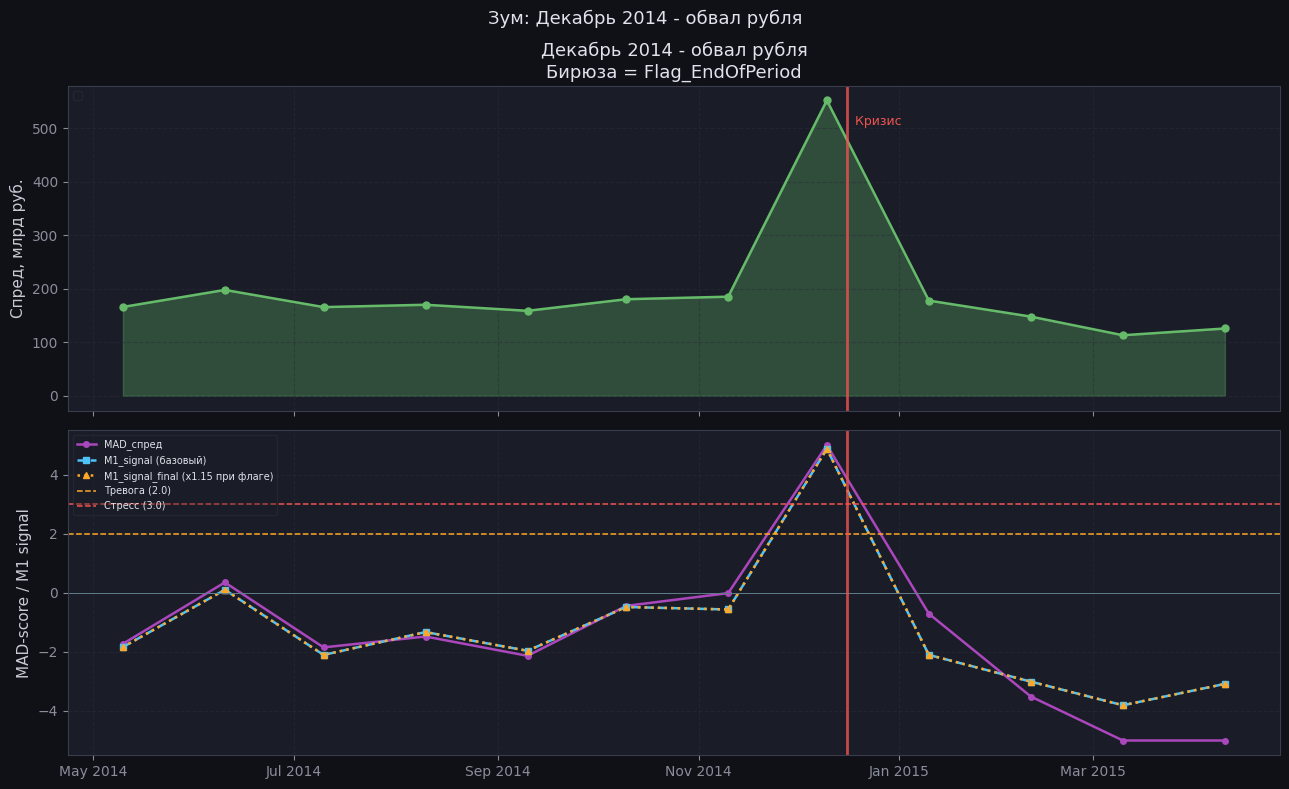

Декабрь 2014:
  MAD > 2 ДО кризиса:            1 периодов
  Flag_EndOfPeriod ДО кризиса:   0 периодов



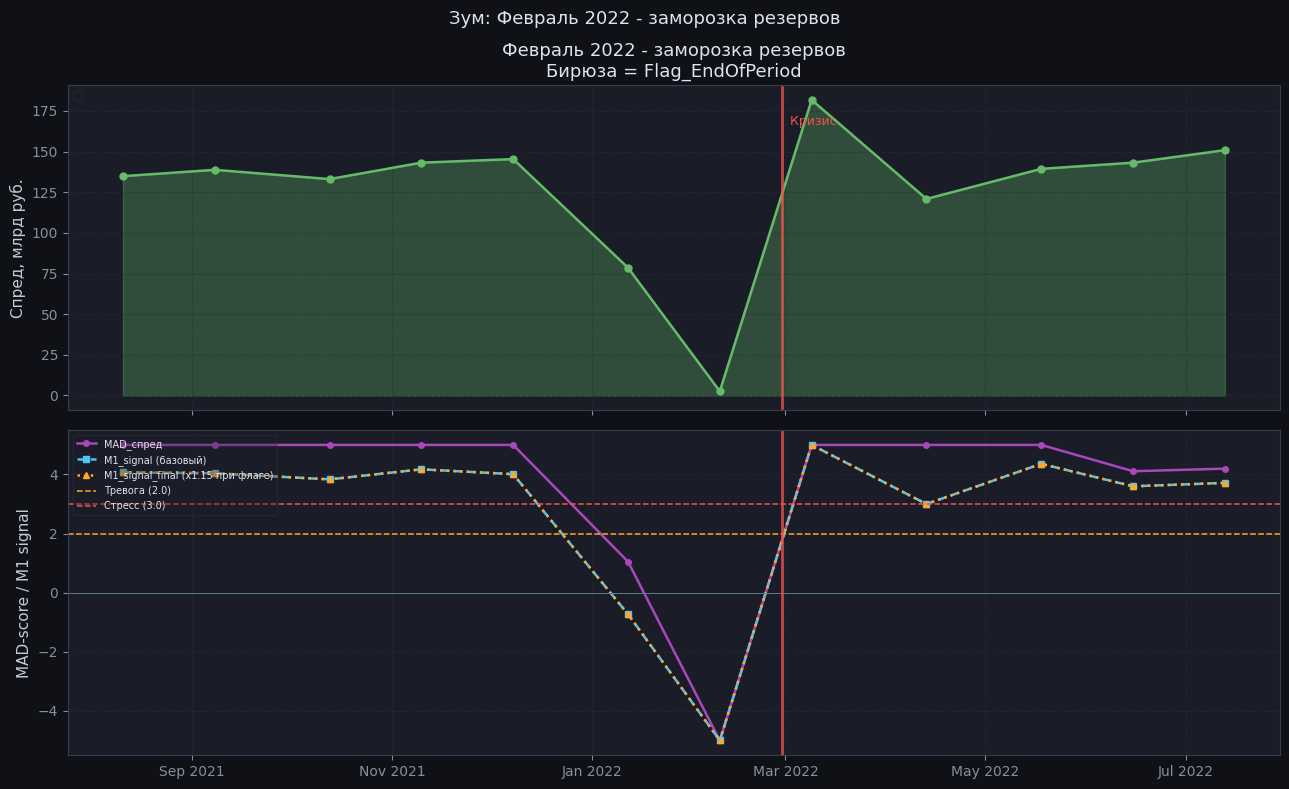

Февраль 2022:
  MAD > 2 ДО кризиса:            5 периодов
  Flag_EndOfPeriod ДО кризиса:   0 периодов



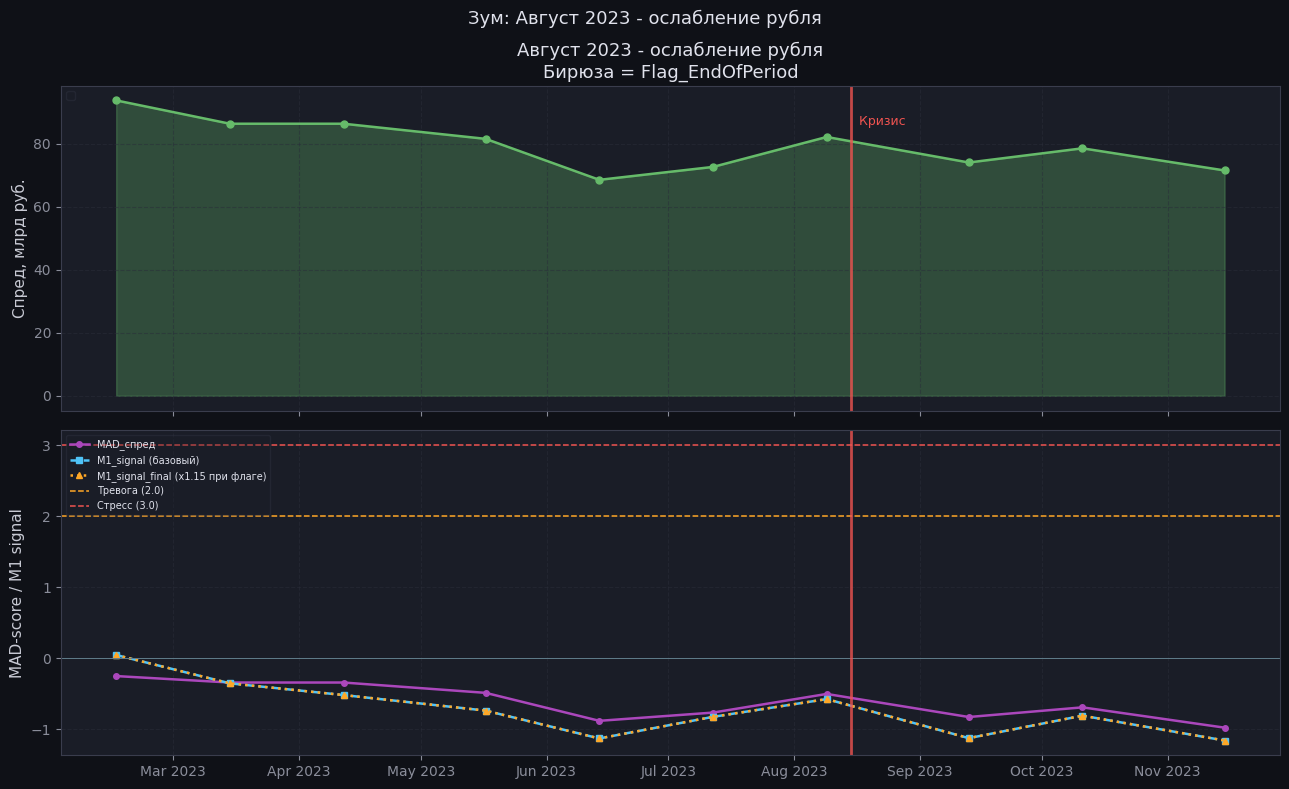

Август 2023:
  MAD > 2 ДО кризиса:            0 периодов
  Flag_EndOfPeriod ДО кризиса:   0 периодов



In [15]:
# ============================================================
# ГРАФИК 6 - Зумы на три стресс-эпизода с Flag_EndOfPeriod
# ============================================================

episodes = [
    ('Декабрь 2014 - обвал рубля', '2014-05-01', '2015-05-01', '2014-12-16'),
    ('Февраль 2022 - заморозка резервов', '2021-08-01', '2022-08-01', '2022-02-28'),
    ('Август 2023 - ослабление рубля', '2023-02-01', '2023-12-01', '2023-08-15'),
]

for title, start, end, crisis in episodes:
    s = df[(df['Дата'] >= start) & (df['Дата'] <= end)].copy()
    if s.empty:
        print(f'Нет данных: {title}')
        continue

    n_rows = 3 if ruonia_has_data else 2
    fig, axes = plt.subplots(n_rows, 1, figsize=(13, 4*n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]
    c_dt = pd.to_datetime(crisis)

    # Субплот 1: спред + Flag_EndOfPeriod
    ax = axes[0]
    ax.fill_between(s['Дата'], s['спред'], alpha=0.3, color=C['green'])
    ax.plot(s['Дата'], s['спред'], color=C['green'], marker='o', ms=5)
    # Бирюзовые зоны = конец периода
    first = True
    for _, row in s[s['Flag_EndOfPeriod']==1].iterrows():
        ax.axvspan(
            row['Дата'] - pd.DateOffset(days=12),
            row['Дата'] + pd.DateOffset(days=12),
            alpha=0.2, color=C['teal'],
            label='Flag_EndOfPeriod' if first else None
        )
        first = False
    ax.axvline(c_dt, color=C['red'], lw=2, alpha=0.8)
    ax.text(c_dt, s['спред'].max()*0.95, '  Кризис',
            color=C['red'], fontsize=9, va='top')
    ax.yaxis.set_major_formatter(FMT_RUB)
    ax.set_ylabel('Спред, млрд руб.')
    ax.set_title(f'{title}\nБирюза = Flag_EndOfPeriod')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True)

    # Субплот 2: M1_signal базовый vs финальный (с флагом)
    ax = axes[1]
    ax.plot(s['Дата'], s['MAD_спред'],
            color=C['purple'], marker='o', ms=4, label='MAD_спред')
    ax.plot(s['Дата'], s['M1_signal'],
            color=C['blue'],   marker='s', ms=4,
            linestyle='--', label='M1_signal (базовый)')
    ax.plot(s['Дата'], s['M1_signal_final'],
            color=C['orange'], marker='^', ms=4,
            linestyle=':', label='M1_signal_final (x1.15 при флаге)')
    # Точки где флаг усилил сигнал
    boosted = s[(s['Flag_EndOfPeriod']==1) & (s['M1_signal']>0)]
    if not boosted.empty:
        ax.scatter(boosted['Дата'], boosted['M1_signal_final'],
                   color=C['teal'], s=80, zorder=5,
                   marker='*', label='Флаг усилил сигнал')
    add_thresh(ax)
    ax.axvline(c_dt, color=C['red'], lw=2, alpha=0.8)
    ax.set_ylabel('MAD-score / M1 signal')
    ax.legend(loc='upper left', fontsize=7)
    ax.grid(True)

    # Субплот 3: RUONIA если есть
    if ruonia_has_data and n_rows == 3:
        ax = axes[2]
        ax.plot(s['Дата'], s['RUONIA_mean'],
                color=C['orange'], marker='o', ms=4, label='RUONIA (среднее)')
        ax.fill_between(s['Дата'],
                        s['RUONIA_mean'].min()*0.95, s['RUONIA_mean'],
                        alpha=0.2, color=C['orange'])
        # Конец периода
        first = True
        for _, row in s[s['Flag_EndOfPeriod']==1].iterrows():
            ax.axvspan(
                row['Дата'] - pd.DateOffset(days=12),
                row['Дата'] + pd.DateOffset(days=12),
                alpha=0.2, color=C['teal'],
                label='Flag_EndOfPeriod' if first else None
            )
            first = False
        ax.axvline(c_dt, color=C['red'], lw=2, alpha=0.8)
        ax.set_ylabel('RUONIA, %')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.suptitle(f'Зум: {title}', fontsize=13)
    plt.tight_layout()
    safe = title.split('-')[0].strip().replace(' ','_')
    plt.savefig(FIGURES_DIR / f'g6_zoom_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

    pre = s[s['Дата'] < c_dt]
    n_warn  = (pre['MAD_спред'].fillna(0) > 2).sum()
    n_flags = (pre['Flag_EndOfPeriod'] == 1).sum()
    print(f'{title.split("-")[0].strip()}:')
    print(f'  MAD > 2 ДО кризиса:            {n_warn} периодов')
    print(f'  Flag_EndOfPeriod ДО кризиса:   {n_flags} периодов')
    print()

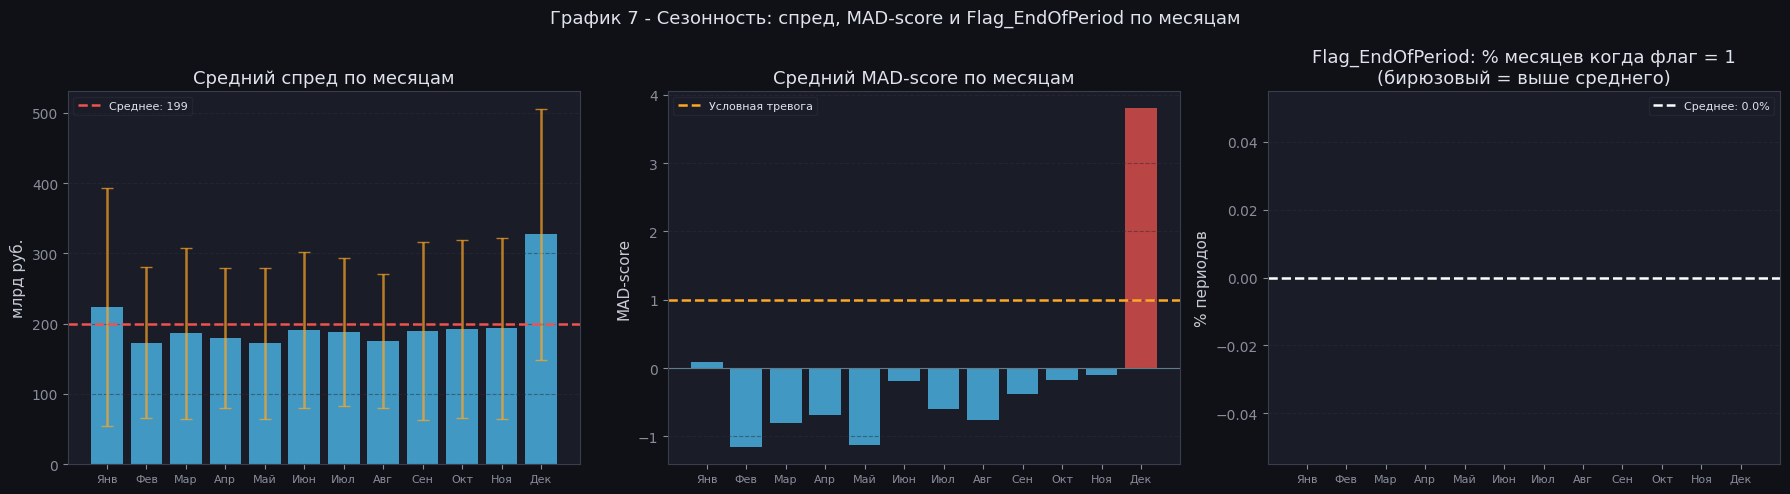

Топ-3 месяца по MAD-score:
  1. Дек: MAD=3.81, Flag_EndOfPeriod=0.0%
  2. Янв: MAD=0.08, Flag_EndOfPeriod=0.0%
  3. Ноя: MAD=-0.11, Flag_EndOfPeriod=0.0%


In [16]:
# ============================================================
# ГРАФИК 7 - Сезонность: в каких месяцах флаг активен чаще?
# ============================================================

m_avg     = df.groupby('месяц')['спред'].mean()
m_std     = df.groupby('месяц')['спред'].std()
m_mad     = df.groupby('месяц')['MAD_спред'].mean()
m_flag    = df.groupby('месяц')['Flag_EndOfPeriod'].mean() * 100
ML = ['Янв','Фев','Мар','Апр','Май','Июн',
      'Июл','Авг','Сен','Окт','Ноя','Дек']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Спред по месяцам
ax1.bar(m_avg.index, m_avg.values, color=C['blue'], alpha=0.75,
        yerr=m_std.values, capsize=4,
        error_kw={'ecolor': C['orange'], 'alpha': 0.7})
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(ML, fontsize=8)
ax1.axhline(m_avg.mean(), color=C['red'], linestyle='--',
            label=f'Среднее: {m_avg.mean():,.0f}')
ax1.yaxis.set_major_formatter(FMT_RUB)
ax1.set_title('Средний спред по месяцам')
ax1.set_ylabel('млрд руб.')
ax1.legend(fontsize=8)
ax1.grid(True, axis='y')

# MAD-score по месяцам
bar_colors2 = [C['red'] if v > 1 else C['blue'] for v in m_mad.values]
ax2.bar(m_mad.index, m_mad.values, color=bar_colors2, alpha=0.75)
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(ML, fontsize=8)
ax2.axhline(0,   color=C['gray'],   linewidth=0.8)
ax2.axhline(1.0, color=C['orange'], linestyle='--', label='Условная тревога')
ax2.set_title('Средний MAD-score по месяцам')
ax2.set_ylabel('MAD-score')
ax2.legend(fontsize=8)
ax2.grid(True, axis='y')

# Flag_EndOfPeriod по месяцам
flag_colors = [C['teal'] if v > m_flag.mean() else C['gray'] for v in m_flag.values]
ax3.bar(m_flag.index, m_flag.values, color=flag_colors, alpha=0.8)
ax3.set_xticks(range(1,13))
ax3.set_xticklabels(ML, fontsize=8)
ax3.axhline(m_flag.mean(), color='white', linestyle='--',
            label=f'Среднее: {m_flag.mean():.1f}%')
ax3.set_title('Flag_EndOfPeriod: % месяцев когда флаг = 1\n'
              '(бирюзовый = выше среднего)')
ax3.set_ylabel('% периодов')
ax3.legend(fontsize=8)
ax3.grid(True, axis='y')

plt.suptitle('График 7 - Сезонность: спред, MAD-score и Flag_EndOfPeriod по месяцам',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'g7_seasonality_flag.png', dpi=150, bbox_inches='tight')
plt.show()

print('Топ-3 месяца по MAD-score:')
for rank, (m, v) in enumerate(
    m_mad.sort_values(ascending=False).head(3).items(), 1
):
    flag_pct = m_flag[m]
    print(f'  {rank}. {ML[m-1]}: MAD={v:.2f}, Flag_EndOfPeriod={flag_pct:.1f}%')

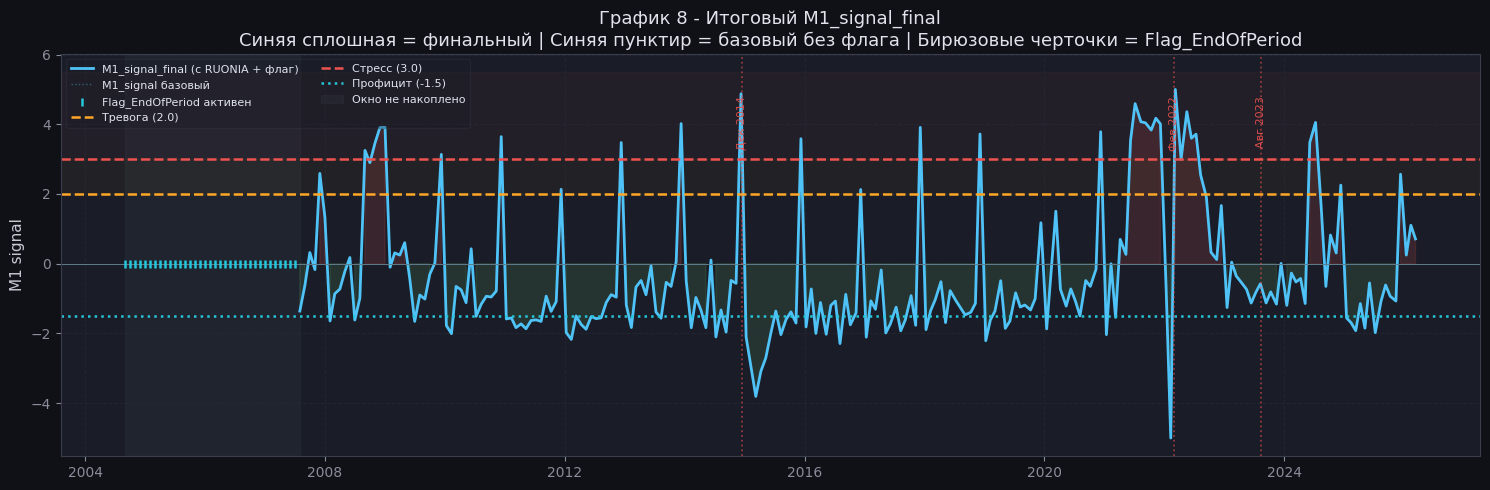

Текущий M1_signal_final: 0.711
Статус: НОРМА
Flag_EndOfPeriod сейчас: 0


In [17]:
# ============================================================
# ГРАФИК 8 - Итоговый M1_signal_final
# ============================================================

fig, ax = plt.subplots(figsize=(15, 5))

sig_final = df['M1_signal_final']
sig_base  = df['M1_signal']

if ruonia_has_data:
    ruonia_start = df.loc[df['MAD_RUONIA'].notna(), 'Дата'].min()
    mask_before  = df['M1_reliable'] & (df['Дата'] < ruonia_start)
    mask_after   = df['M1_reliable'] & (df['Дата'] >= ruonia_start)
else:
    ruonia_start = None
    mask_before  = pd.Series(False, index=df.index)
    mask_after   = df['M1_reliable']

if mask_before.any():
    ax.plot(df.loc[mask_before,'Дата'], sig_final[mask_before],
            color=C['gray'], linewidth=1.2, linestyle='--',
            label='M1 без RUONIA')

if mask_after.any():
    ax.plot(df.loc[mask_after,'Дата'], sig_final[mask_after],
            color=C['blue'], linewidth=2,
            label='M1_signal_final (с RUONIA + флаг)')
    # Пунктиром - базовый без флага для сравнения
    ax.plot(df.loc[mask_after,'Дата'], sig_base[mask_after],
            color=C['blue'], linewidth=1, linestyle=':',
            alpha=0.4, label='M1_signal базовый')

# Закраска зон
ax.fill_between(df['Дата'], 0, sig_final,
                where=(sig_final > 0) & df['M1_reliable'],
                alpha=0.15, color=C['red'])
ax.fill_between(df['Дата'], sig_final, 0,
                where=(sig_final < 0) & df['M1_reliable'],
                alpha=0.15, color=C['green'])

# Точки где флаг был активен
flag_active = df[df['Flag_EndOfPeriod']==1 & df['M1_reliable']]
ax.scatter(flag_active['Дата'], sig_final[flag_active.index],
           color=C['teal'], s=30, zorder=5,
           marker='|', label='Flag_EndOfPeriod активен')

ax.axhline(2.0,  color=C['orange'], linestyle='--', label='Тревога (2.0)')
ax.axhline(3.0,  color=C['red'],    linestyle='--', label='Стресс (3.0)')
ax.axhline(-1.5, color=C['teal'],   linestyle=':',  label='Профицит (-1.5)')
ax.axhline(0,    color=C['gray'],   linewidth=0.7)

unreliable_end = df.loc[df['M1_reliable'], 'Дата'].min()
ax.axvspan(df['Дата'].min(), unreliable_end,
           alpha=0.08, color=C['gray'], label='Окно не накоплено')

if ruonia_start is not None:
    ax.axvline(ruonia_start, color=C['teal'],
               linewidth=1.2, linestyle='-.', alpha=0.7)
    ax.text(ruonia_start,
            sig_final[df['M1_reliable']].max() * 0.85,
            '  +RUONIA', color=C['teal'], fontsize=8, va='top')

sig_max = sig_final[df['M1_reliable']].max() if df['M1_reliable'].any() else 3
ax.axhspan(3.0, sig_max+0.5, alpha=0.04, color=C['red'])
ax.axhspan(2.0, 3.0,         alpha=0.04, color=C['orange'])

mark_stress(ax, sig_max * 0.96)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('График 8 - Итоговый M1_signal_final\n'
             'Синяя сплошная = финальный | Синяя пунктир = базовый без флага | '
             'Бирюзовые черточки = Flag_EndOfPeriod')
ax.set_ylabel('M1 signal')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'g8_m1_signal_final.png', dpi=150, bbox_inches='tight')
plt.show()

last   = df['M1_signal_final'].iloc[-1]
status = 'СТРЕСС' if last >= 3 else ('ТРЕВОГА' if last >= 2 else 'НОРМА')
print(f'Текущий M1_signal_final: {last:.3f}')
print(f'Статус: {status}')
print(f'Flag_EndOfPeriod сейчас: {df["Flag_EndOfPeriod"].iloc[-1]}')

In [18]:
# ============================================================
# ИТОГ - Гипотеза и выход в агрегационный слой
# ============================================================

ML    = ['Янв','Фев','Мар','Апр','Май','Июн',
         'Июл','Авг','Сен','Окт','Ноя','Дек']
m_mad = df.groupby('месяц')['MAD_спред'].mean()

print('=' * 65)
print('  ГИПОТЕЗА МОДУЛЯ М1')
print('=' * 65)
print()
print('ГИПОТЕЗА:')
print('  Рост MAD-score спреда и RUONIA выше 2.0 является')
print('  опережающим сигналом стресса ликвидности за 1-3 мес.')
print('  При активном Flag_EndOfPeriod те же значения сигналов')
print('  несут большую информативность - банки под дедлайном,')
print('  их действия отражают реальную срочную потребность')
print('  в ликвидности, а не плановое управление резервами.')
print()
print('ВАЛИДАЦИЯ НА ИСТОРИЧЕСКИХ ЭПИЗОДАХ:')

for name, date in STRESS.items():
    d    = pd.to_datetime(date)
    mask = df['Дата'].dt.to_period('M') == d.to_period('M')
    vals = df.loc[mask, 'M1_signal_final'].values
    flag = df.loc[mask, 'Flag_EndOfPeriod'].values
    if len(vals) > 0:
        st = 'СТРЕСС' if vals[0] >= 3 else ('ТРЕВОГА' if vals[0] >= 2 else 'НОРМА')
        print(f'  {name}: M1={vals[0]:.2f} ({st}), Flag_EndOfPeriod={int(flag[0]) if len(flag)>0 else "N/A"}')

print()
print('ФАКТЫ ИЗ ДАННЫХ:')

split = pd.to_datetime('2015-01-01')
b1 = df[df['Дата'] < split]['спред_относ'].mean()
b2 = df[df['Дата'] >= split]['спред_относ'].mean()
print(f'  1. Буфер: до 2015 = {b1:.0f}%, после = {b2:.1f}% (в {b1/b2:.0f}x меньше)')

n_warn = (df['MAD_спред'].fillna(0) > 2).sum()
pct    = n_warn / df['MAD_спред'].notna().sum() * 100
print(f'  2. Периодов MAD_спред > 2: {n_warn} ({pct:.1f}%)')

mad_end    = df.loc[df['Flag_EndOfPeriod']==1,'MAD_спред'].dropna().mean()
mad_no_end = df.loc[df['Flag_EndOfPeriod']==0,'MAD_спред'].dropna().mean()
print(f'  3. MAD_спред при Flag=1: {mad_end:.3f} vs Flag=0: {mad_no_end:.3f}')
direction = 'выше' if mad_end > mad_no_end else 'не выше'
print(f'     В конце периода MAD {direction} -> флаг {'обоснован' if mad_end > mad_no_end else 'слабо влияет'}')

top3 = m_mad.sort_values(ascending=False).head(3).index.tolist()
print(f'  4. Стрессовые месяцы: {[ML[m-1] for m in top3]}')

if ruonia_has_data and 'MAD_RUONIA' in df.columns:
    mask = df['MAD_спред'].notna() & df['MAD_RUONIA'].notna()
    rho, p = spearmanr(df.loc[mask,'MAD_спред'], df.loc[mask,'MAD_RUONIA'])
    print(f'  5. Корреляция MAD_спред <-> MAD_RUONIA: r={rho:.3f}')

print()
print('=' * 65)
print('  ВЫХОД М1 -> АГРЕГАЦИОННЫЙ СЛОЙ (LSI)')
print('=' * 65)

out = ['Дата','MAD_спред','MAD_спред_относ','MAD_дельта',
       'Flag_EndOfPeriod','M1_signal','M1_signal_final']
if ruonia_has_data:
    out.insert(3, 'MAD_RUONIA')

print(df[out].tail(5).to_string(index=False))
print()
print('Что идёт в агрегационный слой:')
print('  M1_signal_final  -> основной сигнал (уже учитывает флаг)')
print('  MAD_спред        -> признак для XGBoost')
print('  MAD_спред_относ  -> признак для XGBoost')
if ruonia_has_data:
    print('  MAD_RUONIA       -> признак для XGBoost')
print('  MAD_дельта       -> признак для XGBoost')
print('  Flag_EndOfPeriod -> бинарный признак для XGBoost')

  ГИПОТЕЗА МОДУЛЯ М1

ГИПОТЕЗА:
  Рост MAD-score спреда и RUONIA выше 2.0 является
  опережающим сигналом стресса ликвидности за 1-3 мес.
  При активном Flag_EndOfPeriod те же значения сигналов
  несут большую информативность - банки под дедлайном,
  их действия отражают реальную срочную потребность
  в ликвидности, а не плановое управление резервами.

ВАЛИДАЦИЯ НА ИСТОРИЧЕСКИХ ЭПИЗОДАХ:
  Дек 2014: M1=4.88 (СТРЕСС), Flag_EndOfPeriod=0
  Фев 2022: M1=-5.00 (НОРМА), Flag_EndOfPeriod=0
  Авг 2023: M1=-0.58 (НОРМА), Flag_EndOfPeriod=0

ФАКТЫ ИЗ ДАННЫХ:
  1. Буфер: до 2015 = 571%, после = 5.0% (в 114x меньше)
  2. Периодов MAD_спред > 2: 37 (16.5%)
  3. MAD_спред при Flag=1: nan vs Flag=0: -0.165
     В конце периода MAD не выше -> флаг слабо влияет
  4. Стрессовые месяцы: ['Дек', 'Янв', 'Ноя']

  ВЫХОД М1 -> АГРЕГАЦИОННЫЙ СЛОЙ (LSI)
      Дата  MAD_спред  MAD_спред_относ  MAD_дельта  Flag_EndOfPeriod  M1_signal  M1_signal_final
2025-11-12  -1.398121        -1.171286   -0.141791           